In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import openpyxl
import seaborn as sns
import numpy as np
from jupyterlab.extensions.pypi import xmlrpc_transport_override
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score, roc_auc_score,balanced_accuracy_score
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import optuna
import warnings
from pandas.errors import PerformanceWarning
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression



In [64]:
warnings.simplefilter("ignore", PerformanceWarning) #настройка для игнорирования предупреждений о производительности при работе с большими DataFrame
optuna.logging.set_verbosity(optuna.logging.WARNING)
ntrials = 0

# Prediction for 1 day

In [65]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_1_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)

for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change(fill_method=None)
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# XGBoost

AUC 0.8170338868497395
Accuracy 0.8035495716034272
Precision 0.6882352941176471
Recall 0.3038961038961039
F1 0.42162162162162165


<Axes: >

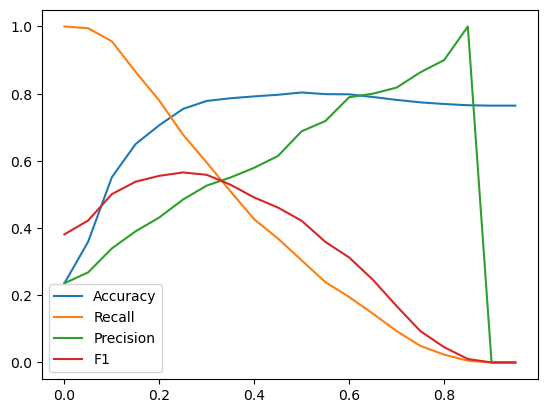

In [66]:

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)

def objective(trial):

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params,dtrain=dtrain,evals=[(dtrain,'train'),(dtest,'test')],
                          num_boost_round=3000, early_stopping_rounds=50,verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc

study = optuna.create_study(
    direction='maximize',storage='sqlite:///xgboost_for_1day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_1day_study'
)

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
study = optuna.load_study(storage='sqlite:///xgboost_for_1day_study.db',study_name='xgboost_for_1day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=False
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')


# SVM 


AUC 0.552624957108544
Accuracy 0.7643818849449204
Precision 0.0
Recall 0.0
F1 0.0


<Axes: >

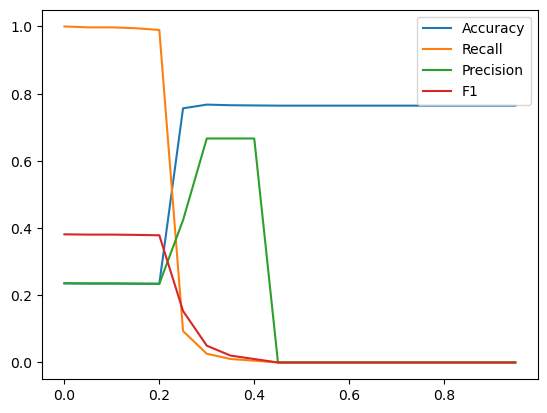

In [67]:
def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc

study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_1day_study.db',
    load_if_exists=True,
    study_name='svc_for_1day_study'
)           

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
study = optuna.load_study(storage='sqlite:///svc_for_1day_study.db',study_name='svc_for_1day_study')
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 1]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   

# AdaBoost

In [68]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10,class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
adaboost_model.fit(x_train, y_train)
y_prob = adaboost_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7844446986160356
Accuracy 0.795593635250918
Precision 0.6976744186046512
Recall 0.23376623376623376
F1 0.0


# RF

In [69]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}
)
rf_model.fit(x_train, y_train)
y_prob = rf_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),     
    zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))  
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0)) 


AUC 0.7438220706435279
Accuracy 0.791921664626683
Precision 0.7368421052631579
Recall 0.18181818181818182
F1 0.0


# EM 

In [70]:
em_model = GaussianMixture(n_components=2, random_state=42)
em_model.fit(x_train,y_train)
y_prob = em_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.5077880486207148
Accuracy 0.5177478580171359
Precision 0.24461343472750316
Recall 0.5012987012987012
F1 0.0
F1 0.0


# Logit

In [71]:
logit_model = LogisticRegression(class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}, max_iter=1000)
logit_model.fit(x_train, y_train)
y_prob = logit_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print("Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7433396067503354
Accuracy 0.784577723378213
Precision 0.5812807881773399
Recall 0.3064935064935065
F1 0.0


# Prediction for 2 day

In [72]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_2_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)

for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change(fill_method=None)
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# SVM

AUC 0.5492622669564223
Accuracy 0.7643818849449204
Precision 0.0
Recall 0.0
F1 0.0


<Axes: >

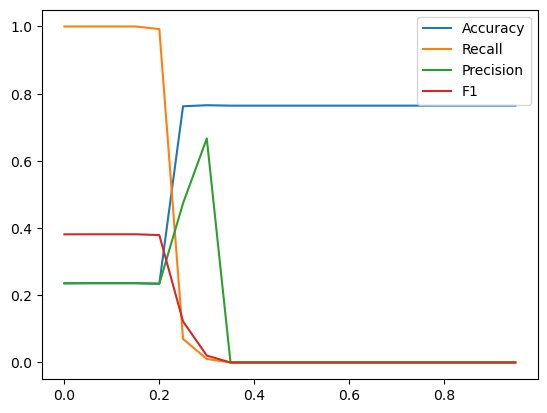

In [73]:
def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc

study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_2day_study.db',
    load_if_exists=True,
    study_name='svc_for_2day_study'
)           

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
study = optuna.load_study(storage='sqlite:///svc_for_2day_study.db',study_name='svc_for_2day_study')
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 1]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   





# XGBoost

AUC 0.8392480217940586
Accuracy 0.8053855569155447
Precision 0.7055214723926381
Recall 0.2987012987012987
F1 0.4197080291970803


<Axes: >

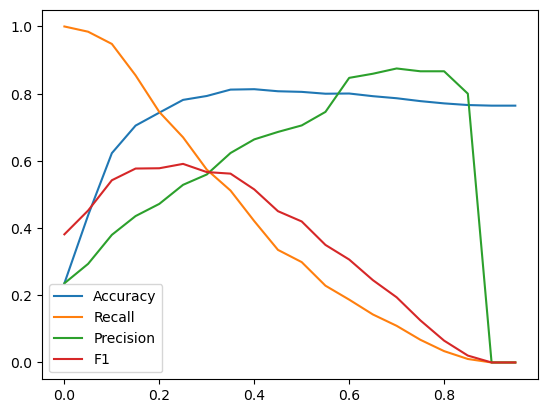

In [74]:

scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_2day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_2day_study'
)

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
study = optuna.load_study(storage='sqlite:///xgboost_for_2day_study.db',study_name='xgboost_for_2day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,verbose_eval=False
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')


# AdaBoost

In [75]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10,class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
adaboost_model.fit(x_train, y_train)
y_prob = adaboost_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7920299876264648
Accuracy 0.7943696450428397
Precision 0.6666666666666666
Recall 0.2545454545454545
F1 0.0


# RF

In [76]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}
)
rf_model.fit(x_train, y_train)
y_prob = rf_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),     
    zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))  
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0)) 


AUC 0.752797562725505
Accuracy 0.7980416156670747
Precision 0.7570093457943925
Recall 0.21038961038961038
F1 0.0


# EM

In [77]:
em_model = GaussianMixture(n_components=2, random_state=42)
em_model.fit(x_train,y_train)
y_prob = em_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.4953905981928399
Accuracy 0.5960832313341493
Precision 0.24394785847299813
Recall 0.34025974025974026
F1 0.0


# Logit

In [78]:
logit_model = LogisticRegression(class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}, max_iter=1000)
logit_model.fit(x_train, y_train)
y_prob = logit_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print("Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7605024279163591
Accuracy 0.7827417380660955
Precision 0.5646551724137931
Recall 0.34025974025974026
F1 0.0


# Prediction for 3 day

In [79]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_3_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)

for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change(fill_method=None)
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# SVM

AUC 0.5369838494838495
Accuracy 0.7642375995101041
Precision 0.0
Recall 0.0
F1 0.0


<Axes: >

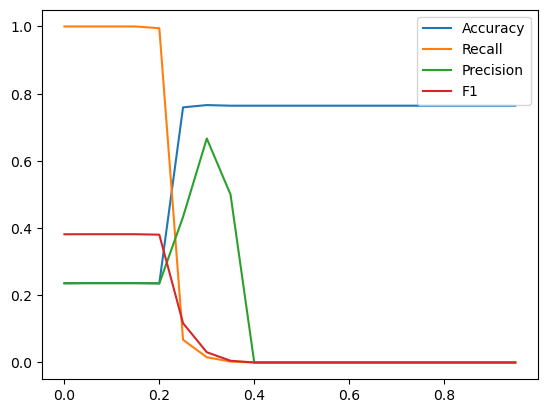

In [80]:

def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc

study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_3day_study.db',
    load_if_exists=True,
    study_name='svc_for_3day_study'
)           

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
study = optuna.load_study(storage='sqlite:///svc_for_3day_study.db',study_name='svc_for_3day_study')
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 1]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   

# XGBoost

AUC 0.850214368964369
Accuracy 0.8120024494794856
Precision 0.7267441860465116
Recall 0.3246753246753247
F1 0.4488330341113106


<Axes: >

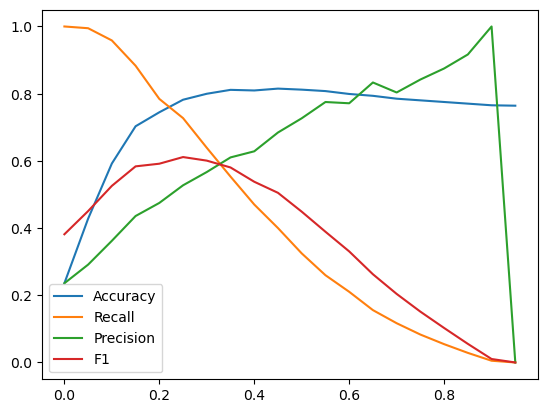

In [81]:

scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_3day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_3day_study'
)

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
study = optuna.load_study(storage='sqlite:///xgboost_for_3day_study.db',study_name='xgboost_for_3day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=False
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')


# AdaBoost

In [82]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10,class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
adaboost_model.fit(x_train, y_train)
y_prob = adaboost_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7975285131535133
Accuracy 0.7973055725658298
Precision 0.6928571428571428
Recall 0.2519480519480519
F1 0.0


# RF

In [83]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}
)
rf_model.fit(x_train, y_train)
y_prob = rf_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),     
    zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))


AUC 0.7625645188145189
Accuracy 0.8015921616656461
Precision 0.7652173913043478
Recall 0.22857142857142856
F1 0.0


# EM

In [84]:
em_model = GaussianMixture(n_components=2, random_state=42)
em_model.fit(x_train,y_train)
y_prob = em_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.4926729520479521
Accuracy 0.5358236374770361
Precision 0.23842917251051893
Recall 0.44155844155844154
F1 0.0


# Logit

In [85]:
logit_model = LogisticRegression(class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}, max_iter=1000)
logit_model.fit(x_train, y_train)
y_prob = logit_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print("Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7773434898434898
Accuracy 0.799755052051439
Precision 0.625
Recall 0.37662337662337664
F1 0.0


# Prediction for 4 day

In [86]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_4_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)
for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change(fill_method=None)
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# SVM

AUC 0.7658154345654347
Accuracy 0.7875076546233926
Precision 0.5772357723577236
Recall 0.36883116883116884
F1 0.4500792393026941


<Axes: >

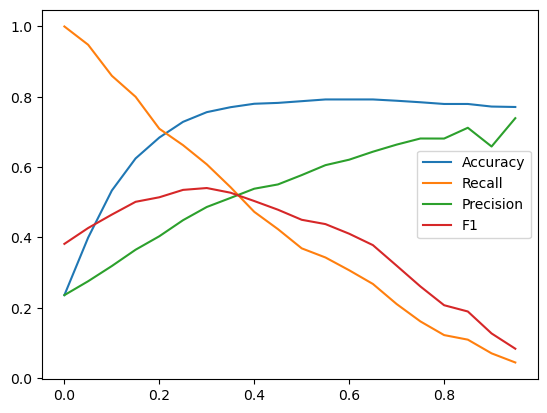

In [87]:

def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc

study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_4day_study.db',
    load_if_exists=True,
    study_name='svc_for_4day_study'
)           

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
study = optuna.load_study(storage='sqlite:///svc_for_4day_study.db',study_name='svc_for_4day_study')
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 1]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   

# XGBoost

AUC 0.8673805361305361
Accuracy 0.8254745866503368
Precision 0.7336448598130841
Recall 0.4077922077922078
F1 0.5242070116861436


<Axes: >

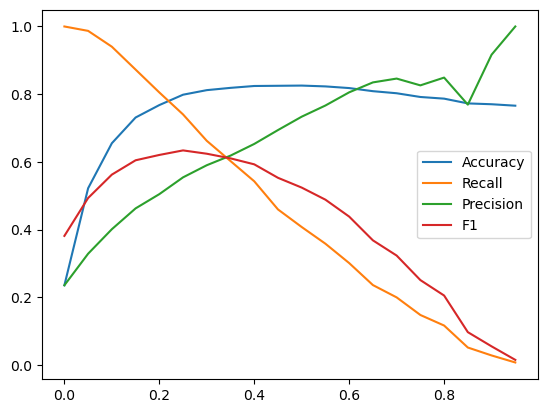

In [88]:

scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_4day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_4day_study'
)

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
study = optuna.load_study(storage='sqlite:///xgboost_for_4day_study.db',study_name='xgboost_for_4day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=False
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')


# AdaBoost

In [89]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10,class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
adaboost_model.fit(x_train, y_train)
y_prob = adaboost_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7744089244089243
Accuracy 0.7703612982241274
Precision 0.5192307692307693
Recall 0.35064935064935066
F1 0.015463917525773196


# RF

In [90]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}
)
rf_model.fit(x_train, y_train)
y_prob = rf_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),     
    zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))


AUC 0.768691724941725
Accuracy 0.7960808328230251
Precision 0.7363636363636363
Recall 0.21038961038961038
F1 0.015463917525773196


# EM

In [91]:
em_model = GaussianMixture(n_components=2, random_state=42)
em_model.fit(x_train,y_train)
y_prob = em_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.5066943473193473
Accuracy 0.5009185548071035
Precision 0.24343675417661098
Recall 0.5298701298701298
F1 0.015463917525773196


# Logit

In [92]:
logit_model = LogisticRegression(class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}, max_iter=1000)
logit_model.fit(x_train, y_train)
y_prob = logit_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print("Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))  
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0)) 

AUC 0.7905656843156843
Accuracy 0.799755052051439
Precision 0.625
Recall 0.37662337662337664
F1 0.015463917525773196


# Prediction for 5 day

In [93]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_5_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)
for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change(fill_method=None)
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# SVM

AUC 0.5439069350857643
Accuracy 0.7640931372549019
Precision 0.0
Recall 0.0
F1 0.0


<Axes: >

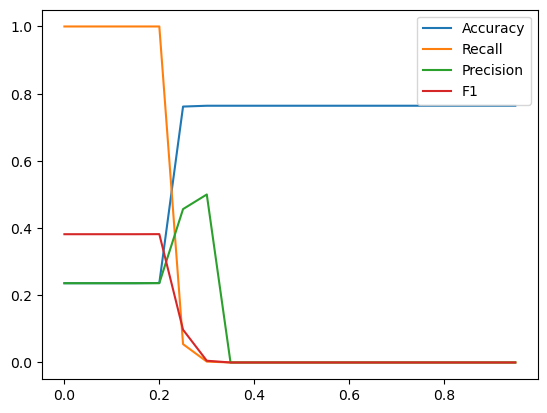

In [94]:
def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc
study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_5day_study.db',
    load_if_exists=True,
    study_name='svc_for_5day_study'
)           

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
study = optuna.load_study(storage='sqlite:///svc_for_5day_study.db',study_name='svc_for_5day_study')
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 1]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   

# XGBoost

AUC 0.8706485174809152
Accuracy 0.8131127450980392
Precision 0.7150537634408602
Recall 0.34545454545454546
F1 0.4658493870402802


<Axes: >

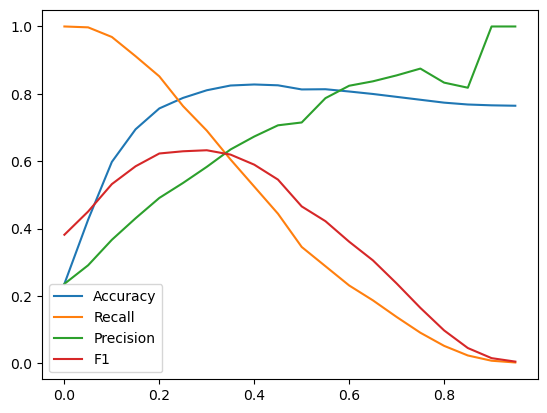

In [95]:
scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_5day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_5day_study'
)

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
study = optuna.load_study(storage='sqlite:///xgboost_for_5day_study.db',study_name='xgboost_for_5day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=False
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# AdaBoost

In [96]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10,class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
adaboost_model.fit(x_train, y_train)
y_prob = adaboost_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7839344296441328
Accuracy 0.7879901960784313
Precision 0.6089385474860335
Recall 0.2831168831168831
F1 0.0051813471502590676


# RF

In [97]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}
)
rf_model.fit(x_train, y_train)
y_prob = rf_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),     
    zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))


AUC 0.7734635853320697
Accuracy 0.8008578431372549
Precision 0.7777777777777778
Recall 0.21818181818181817
F1 0.0051813471502590676


# EM

In [98]:
em_model = GaussianMixture(n_components=2, random_state=42)
em_model.fit(x_train,y_train)
y_prob = em_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.4988002374530041
Accuracy 0.5386029411764706
Precision 0.24794520547945206
Recall 0.4701298701298701
F1 0.0051813471502590676


# Logit

In [99]:
logit_model = LogisticRegression(class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}, max_iter=1000)
logit_model.fit(x_train, y_train)
y_prob = logit_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print("Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.8038284089607265
Accuracy 0.7990196078431373
Precision 0.6108949416342413
Recall 0.4077922077922078
F1 0.0051813471502590676


# Prediction for 6 days


In [100]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_6_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)
for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change(fill_method=None)
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# SVM

AUC 0.806347702017309
Accuracy 0.7861519607843137
Precision 0.576271186440678
Recall 0.35324675324675325
F1 0.43800322061191627


<Axes: >

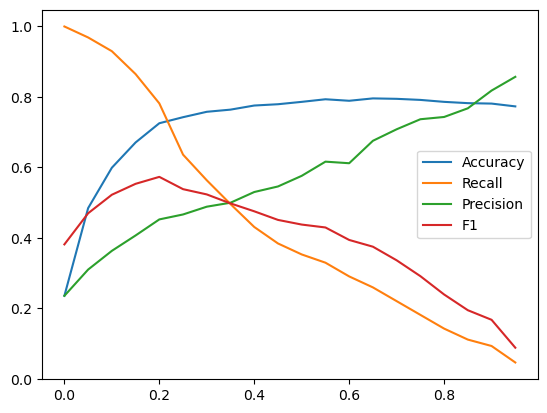

In [101]:
def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc
study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_6day_study.db',
    load_if_exists=True,
    study_name='svc_for_6day_study'
)           

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
study = optuna.load_study(storage='sqlite:///svc_for_6day_study.db',study_name='svc_for_6day_study')
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 1]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   

# XGBoost

AUC 0.8795384246867807
Accuracy 0.8192401960784313
Precision 0.7295918367346939
Recall 0.37142857142857144
F1 0.49225473321858865


<Axes: >

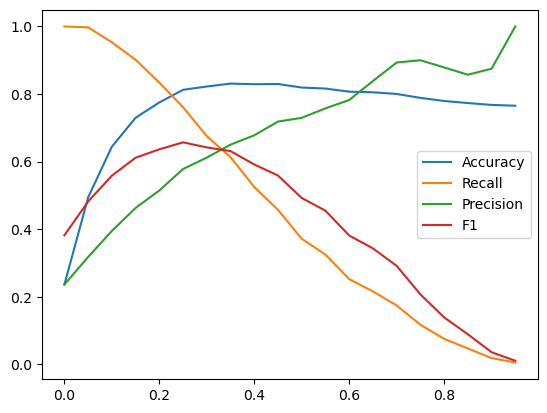

In [102]:
scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_6day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_6day_study'
)

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
study = optuna.load_study(storage='sqlite:///xgboost_for_6day_study.db',study_name='xgboost_for_6day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=False
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# AdaBoost

In [103]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10,class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
adaboost_model.fit(x_train, y_train)
y_prob = adaboost_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7695966423312053
Accuracy 0.7640931372549019
Precision 0.5
Recall 0.3168831168831169
F1 0.0103359173126615


# RF

In [104]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}
)
rf_model.fit(x_train, y_train)
y_prob = rf_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),     
    zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))


AUC 0.776612962017934
Accuracy 0.7965686274509803
Precision 0.7345132743362832
Recall 0.21558441558441557
F1 0.0103359173126615


# EM

In [105]:
em_model = GaussianMixture(n_components=2, random_state=42)
em_model.fit(x_train,y_train)
y_prob = em_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.5038200772763723
Accuracy 0.3946078431372549
Precision 0.23342175066312998
Recall 0.6857142857142857
F1 0.0103359173126615


# Logit

In [106]:
logit_model = LogisticRegression(class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}, max_iter=1000)
logit_model.fit(x_train, y_train)
y_prob = logit_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print("Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.8188733479832117
Accuracy 0.8082107843137255
Precision 0.65
Recall 0.4051948051948052
F1 0.0103359173126615


# Prediction for 7 days

In [107]:
file_path = '/Users/vladislav/Desktop/Данные/predictions_for_6_days.xlsx'
data = pd.read_excel(file_path,index_col='TRADEDATE')
sifts = range(1,30)
for j in (data.drop('crisis',axis=1)).columns:
    data[j] = data[j].pct_change(fill_method=None)
data_copy = data.copy()
for sh in sifts:
    for j in (data_copy.drop('crisis',axis=1)).columns:
        data[f'{j}_lag_{sh}'] = data[j].shift(sh)
imputer = SimpleImputer(strategy='median')
train = data.iloc[:int(len(data)*0.6),:]
test = data.iloc[int(len(data)*0.6):,:]
x_train = train.drop('crisis',axis=1)
y_train = train['crisis']
x_test = test.drop('crisis',axis=1)
y_test = test['crisis']
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# SVM

AUC 0.5504452243826743
Accuracy 0.7640931372549019
Precision 0.0
Recall 0.0
F1 0.0


<Axes: >

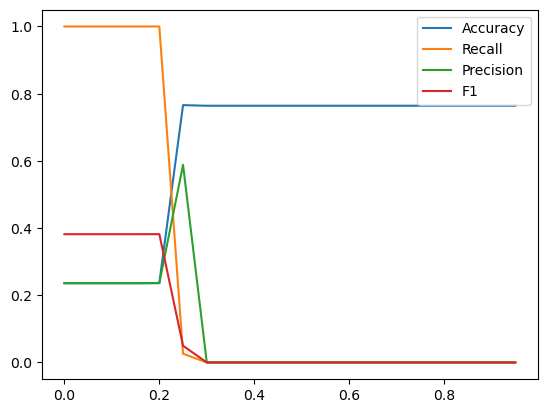

In [108]:
def objective(trial):
    params = {'kernel':trial.suggest_categorical('kernel', ['poly','rbf'])}
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
    elif params['kernel'] == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-3, 4,)
    class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
    svc_model = SVC(kernel='rbf',gamma=3,probability=True,class_weight=class_weight)
    svc_model.fit(x_train,y_train)
    y_pred = svc_model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    return auc
study = optuna.create_study(
    direction='maximize',storage='sqlite:///svc_for_7day_study.db',
    load_if_exists=True,
    study_name='svc_for_7day_study'
)           

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
class_weight = {0:(y_train == 0).sum(),
                1:(y_train == 1).sum()}
study = optuna.load_study(storage='sqlite:///svc_for_7day_study.db',study_name='svc_for_7day_study')
best_params = study.best_params
svc_model = SVC(kernel='rbf',probability=True,class_weight=class_weight)
svc_model.set_params(**best_params)
svc_model.fit(x_train,y_train)
y_prob = svc_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print(    "Recall",
    recall_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        (y_prob > 0.5).astype(int),
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = svc_model.predict_proba(x_test)[:, 1]
    y_pred = (
    y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')   

# XGBoost

AUC 0.8799716722731958
Accuracy 0.8235294117647058
Precision 0.7255813953488373
Recall 0.4051948051948052
F1 0.52


<Axes: >

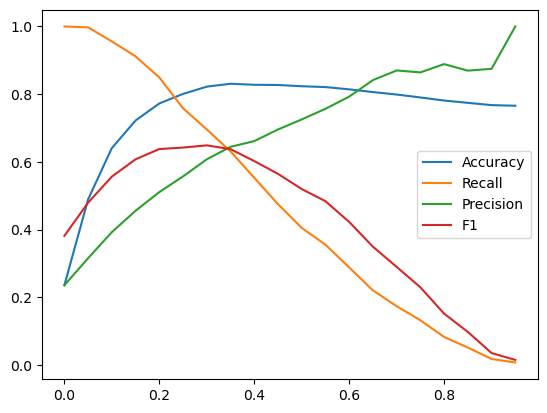

In [109]:
scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
)
dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)


def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int(
            'max_depth',
            2,
            8
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.005,
            0.1,
            log=True
        ),
        'subsample': trial.suggest_float(
            'subsample',
            0.5,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.5,
            1.0
        ),
        'lambda': trial.suggest_float(
            'lambda',
            1e-3,
            10,
            log=True
        ),

        'alpha': trial.suggest_float(
            'alpha',
            1e-3,
            10,
            log=True
        ),
        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    xgb_model = xgb.train(params, dtrain=dtrain, evals=[(dtrain, 'train'), (dtest, 'test')],
                          num_boost_round=3000, early_stopping_rounds=50, verbose_eval=False)
    y_prob = xgb_model.predict(dtest)
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    return auc


study = optuna.create_study(
    direction='maximize', storage='sqlite:///xgboost_for_7day_study.db',
    load_if_exists=True,
    study_name='xgboost_for_7day_study'
)

study.optimize(
    objective,
    n_trials=ntrials,
    show_progress_bar=True
)
study = optuna.load_study(storage='sqlite:///xgboost_for_7day_study.db',study_name='xgboost_for_7day_study')
params = {'objective': 'binary:logistic',
        'eval_metric': 'auc',
          'seed': 42}
params.update(study.best_params)
model_xgb = xgb.train(
    params,
    dtrain=dtrain,
    evals=[(dtrain,'train'),(dtest,'test')],
    num_boost_round=3000,
    early_stopping_rounds=100,
    verbose_eval=False
)
y_prob = model_xgb.predict(dtest)
threshold = 0.5
y_pred = (
    y_prob > threshold
).astype(int)
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(
        y_test,
        y_pred,
        zero_division=0))
print(
    "Recall",
    recall_score(
        y_test,
        y_pred,
        zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))
Accuracy = []
Recall = []
Per = []
Tr = []
F1 = []
for t in np.arange(0,1,0.05):
    y_prob = model_xgb.predict(dtest)
    y_pred = (y_prob > t
).astype(int)
    Accuracy.append(accuracy_score(y_test, y_pred))
    Recall.append(recall_score(y_test, y_pred, zero_division=0))
    Per.append(precision_score(y_test, y_pred, zero_division=0))
    F1.append(f1_score(y_test, y_pred, zero_division=0))
    Tr.append(t)
plt.figure()
sns.lineplot(x = Tr,y = Accuracy,label = 'Accuracy')
sns.lineplot(x = Tr,y = Recall,label = 'Recall')
sns.lineplot(x = Tr,y = Per, label = 'Precision')
sns.lineplot(x = Tr,y = F1, label = 'F1')

# AdaBoost

In [110]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
adaboost_model.fit(x_train, y_train)
y_prob = adaboost_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.7695966423312053
Accuracy 0.7640931372549019
Precision 0.5
Recall 0.3168831168831169
F1 0.015463917525773196


# RF

In [111]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}
)
rf_model.fit(x_train, y_train)
y_prob = rf_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),     
    zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))   
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.776612962017934
Accuracy 0.7965686274509803
Precision 0.7345132743362832
Recall 0.21558441558441557
F1 0.015463917525773196


# EM

In [112]:
em_model = GaussianMixture(n_components=2, random_state=42)
em_model.fit(x_train,y_train)
y_prob = em_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print( "Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0))

AUC 0.5038200772763723
Accuracy 0.3946078431372549
Precision 0.23342175066312998
Recall 0.6857142857142857
F1 0.015463917525773196


# Logit

In [113]:
logit_model = LogisticRegression(class_weight={0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}, max_iter=1000)
logit_model.fit(x_train, y_train)
y_prob = logit_model.predict_proba(x_test)[:, 1]
print("AUC",roc_auc_score(y_test, y_prob))
print("Accuracy",accuracy_score(y_test, (y_prob > 0.5).astype(int)))
print("Precision",precision_score(
        y_test, (y_prob > 0.5).astype(int),
        zero_division=0))
print("Recall",
    recall_score(y_test, (y_prob > 0.5).astype(int),zero_division=0))  
print("F1",
    f1_score(
        y_test,
        y_pred,
        zero_division=0)) 

AUC 0.8188733479832117
Accuracy 0.8082107843137255
Precision 0.65
Recall 0.4051948051948052
F1 0.015463917525773196
